In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pickle

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

In [71]:
df = pd.read_csv("synthetic_disaster_events_2025.csv")
df.head()

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
0,1,Wildfire,Chile,-34.681672,-71.819529,2025-08-27,8,31104,2768213.39,5.12,Yes,0.59,1
1,2,Hurricane,India,22.128569,78.023951,2023-05-29,5,29340,5996226.87,44.43,No,0.26,0
2,3,Volcanic Eruption,Italy,42.316058,11.031447,2023-01-15,7,34804,9222541.48,49.30,No,0.94,1
3,4,Drought,Chile,-33.436253,-69.984615,2024-02-08,8,31191,1827703.09,65.56,Yes,0.94,1
4,5,Volcanic Eruption,Turkey,39.400977,37.006822,2023-12-23,8,46284,13435921.49,60.96,No,0.92,1


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_id                     20000 non-null  int64  
 1   disaster_type                20000 non-null  object 
 2   location                     20000 non-null  object 
 3   latitude                     20000 non-null  float64
 4   longitude                    20000 non-null  float64
 5   date                         20000 non-null  object 
 6   severity_level               20000 non-null  int64  
 7   affected_population          20000 non-null  int64  
 8   estimated_economic_loss_usd  20000 non-null  float64
 9   response_time_hours          20000 non-null  float64
 10  aid_provided                 20000 non-null  object 
 11  infrastructure_damage_index  20000 non-null  float64
 12  is_major_disaster            20000 non-null  int64  
dtypes: float64(5), i

In [73]:
df.isnull().sum()

event_id                       0
disaster_type                  0
location                       0
latitude                       0
longitude                      0
date                           0
severity_level                 0
affected_population            0
estimated_economic_loss_usd    0
response_time_hours            0
aid_provided                   0
infrastructure_damage_index    0
is_major_disaster              0
dtype: int64

In [74]:
df.duplicated().sum()

np.int64(0)

In [75]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

df.drop(columns=["date"], inplace=True)

In [76]:
X = df.drop(columns=["is_major_disaster"], axis = 1)
y = df["is_major_disaster"]

In [77]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train,X_val,y_train,y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=21,
    stratify=y_train_full
)

In [78]:
num_cols = X.select_dtypes(exclude="object").columns
cat_cols = X.select_dtypes(include="object").columns

In [79]:
preprocessor = ColumnTransformer([("num", MinMaxScaler(), num_cols),("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

In [80]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [81]:
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

In [87]:
model = Sequential([
Input(shape=(X_train_t.shape[1],)),
Dense(32,activation="relu"),
Dense(64,activation="relu"),
Dense(1,activation="sigmoid")])

In [88]:
model.compile(optimizer="Adam",loss="binary_crossentropy",metrics=["accuracy"])

In [89]:
early = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

In [90]:
model.fit(X_train_t,y_train,epochs=50,validation_data=(X_val_t,y_val),batch_size=256,callbacks=[early],verbose=2)

Epoch 1/50
50/50 - 4s - 76ms/step - accuracy: 0.6630 - loss: 0.6205 - val_accuracy: 0.8250 - val_loss: 0.4976
Epoch 2/50
50/50 - 0s - 8ms/step - accuracy: 0.9032 - loss: 0.3439 - val_accuracy: 0.9366 - val_loss: 0.2224
Epoch 3/50
50/50 - 0s - 8ms/step - accuracy: 0.9446 - loss: 0.1746 - val_accuracy: 0.9472 - val_loss: 0.1471
Epoch 4/50
50/50 - 0s - 9ms/step - accuracy: 0.9583 - loss: 0.1257 - val_accuracy: 0.9538 - val_loss: 0.1220
Epoch 5/50
50/50 - 0s - 9ms/step - accuracy: 0.9649 - loss: 0.1010 - val_accuracy: 0.9675 - val_loss: 0.0954
Epoch 6/50
50/50 - 0s - 9ms/step - accuracy: 0.9756 - loss: 0.0822 - val_accuracy: 0.9759 - val_loss: 0.0790
Epoch 7/50
50/50 - 0s - 8ms/step - accuracy: 0.9819 - loss: 0.0694 - val_accuracy: 0.9837 - val_loss: 0.0669
Epoch 8/50
50/50 - 0s - 8ms/step - accuracy: 0.9895 - loss: 0.0577 - val_accuracy: 0.9887 - val_loss: 0.0571
Epoch 9/50
50/50 - 1s - 10ms/step - accuracy: 0.9942 - loss: 0.0487 - val_accuracy: 0.9922 - val_loss: 0.0485
Epoch 10/50
50/50

In [91]:
y_pred = np.where(model.predict(X_test_t)>0.5,1,0)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   


In [92]:
accuracy_score(y_pred,y_test)

0.9995

In [93]:
smote = SMOTE()
X_train_res,y_train_res = smote.fit_resample(X_train_t,y_train)

In [94]:
def objective(trial):
    lr_rate = trial.suggest_float('learning_rate',1e-4,1e-2,log=True)

    n_layers = trial.suggest_int('n_layers',1,4)

    optimizer_name = trial.suggest_categorical('optimizer',['Adam', 'RMSprop', 'SGD'])
    activation = trial.suggest_categorical('activation',['tanh', 'relu'])

    batch_size1 = trial.suggest_categorical('batch_size',[32, 64, 128, 256, 512])

    model = Sequential()

    model.add(Input(shape=(X_train_res.shape[1],))
    )

    for i in range(n_layers):
        units = trial.suggest_int(f'units{i}', 8, 96)

        dropout = trial.suggest_float(f'dropout{i}',0.0,0.5)

        reg = trial.suggest_float(f'reg{i}',1e-5,1e-2,log=True)

        model.add(Dense(units,activation=activation,kernel_regularizer=l1_l2(l1=reg,l2=reg))
        )

        model.add(BatchNormalization())

        model.add(Dropout(dropout))

    # Output layer (outside the loop)
    model.add(Dense(1,activation='sigmoid'))

    opt_map = {'Adam': Adam(learning_rate=lr_rate),'RMSprop': RMSprop(learning_rate=lr_rate),'SGD': SGD(learning_rate=lr_rate)}

    model.compile(optimizer=opt_map[optimizer_name],loss='binary_crossentropy',metrics=[tf.keras.metrics.Recall(name='recall')])

    es = EarlyStopping(monitor='val_recall',mode='max',patience=5,restore_best_weights=True)

    history = model.fit(X_train_res,y_train_res,epochs=30,batch_size=batch_size1,validation_data=(X_val_t, y_val),callbacks=[es],verbose=0)

    return max(history.history['val_recall'])

In [97]:
!pip install optuna

  Using cached optuna-4.9.0-py3-none-any.whl.metadata (15 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached mako-1.3.12-py3-none-any.whl.metadata (2.9 kB)
Using cached optuna-4.9.0-py3-none-any.whl (425 kB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.12-py3-none-any.whl (78 kB)

   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   ---------- ----------------------------- 1/4 [colorlog]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ---------------

In [98]:
import optuna

study = optuna.create_study(direction='maximize',
sampler=optuna.samplers.TPESampler(seed=21))
study.optimize(objective,n_trials=5,)
show_progress_bar=True

[I 2026-06-30 08:52:29,370] A new study created in memory with name: no-name-b0db6ee8-2043-40d0-99e0-c21467e46fb2
[I 2026-06-30 08:52:50,633] Trial 0 finished with value: 0.9546874761581421 and parameters: {'learning_rate': 0.0001251554487151282, 'n_layers': 2, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 512, 'units0': 19, 'dropout0': 0.08906233077974918, 'reg0': 0.00030746001885481724, 'units1': 84, 'dropout1': 0.37947191775605715, 'reg1': 0.008155589837765905}. Best is trial 0 with value: 0.9546874761581421.
[I 2026-06-30 08:53:17,324] Trial 1 finished with value: 0.999218761920929 and parameters: {'learning_rate': 0.00330069279804087, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 32, 'units0': 37, 'dropout0': 0.23007016689648802, 'reg0': 0.0004296403664910425, 'units1': 27, 'dropout1': 0.39993416346948824, 'reg1': 0.001513747182776292}. Best is trial 1 with value: 0.999218761920929.
[I 2026-06-30 08:53:37,970] Trial 2 finished with value: 0.

In [99]:
study.best_params

{'learning_rate': 0.00330069279804087,
 'n_layers': 2,
 'optimizer': 'RMSprop',
 'activation': 'relu',
 'batch_size': 32,
 'units0': 37,
 'dropout0': 0.23007016689648802,
 'reg0': 0.0004296403664910425,
 'units1': 27,
 'dropout1': 0.39993416346948824,
 'reg1': 0.001513747182776292}

In [106]:
model = Sequential()

# Input layer
model.add(Input(shape=(X_train_res.shape[1],)))

# First hidden layer
model.add(Dense(37,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=0.0004296403664910425,l2=0.0004296403664910425)))
model.add(BatchNormalization())
model.add(Dropout(0.23007016689648802))

# Second hidden layer
model.add(Dense(27,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=0.001513747182776292,l2=0.001513747182776292)))
model.add(BatchNormalization())
model.add(Dropout(0.39993416346948824))

# Output layer
model.add(Dense(1,activation='sigmoid',kernel_initializer='glorot_uniform'))

# Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# Display model summary
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                     │ (None, 37)                  │           1,073 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 37)                  │             148 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 37)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_39 (Dense)                     │ (None, 27)                  │           1,026 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 27)                  │             108 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 27)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_40 (Dense)                     │ (None, 1)                   │              28 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,383 (9.31 KB)

 Trainable params: 2,255 (8.81 KB)

 Non-trainable params: 128 (512.00 B)

In [107]:
model.compile(optimizer=RMSprop(learning_rate=0.00330069279804087),loss='binary_crossentropy',
metrics=["accuracy",tf.keras.metrics.Recall(name='recall')])

In [108]:
es = EarlyStopping(monitor='val_recall',mode='max',patience=5,restore_best_weights=True)
history = model.fit(X_train_res,y_train_res,epochs=30,batch_size=32,
validation_data=(X_val_t,y_val),callbacks=[es],verbose=0)

In [109]:
y_pred_test = np.where(model.predict(X_test_t)>0.5,1,0)
accuracy_score(y_test,y_pred_test)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step   


0.99875

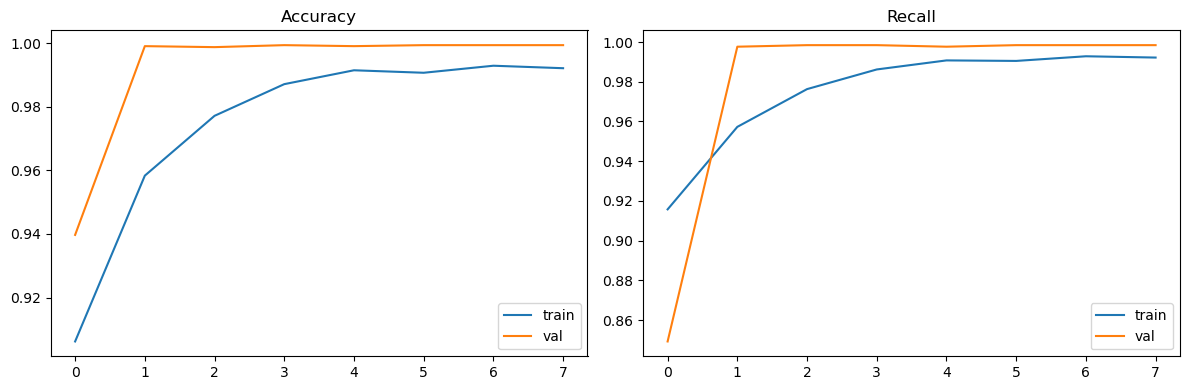

In [111]:
# Learning Curves
fig, axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(history.history['accuracy'],label='train')
axes[0].plot(history.history['val_accuracy'],label='val')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(history.history['recall'],label='train')
axes[1].plot(history.history['val_recall'],label='val')
axes[1].set_title('Recall')
axes[1].legend()
plt.tight_layout()
plt.show()

In [112]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2400
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [113]:
with open('preprocessor.pkl','wb') as f:
    pickle.dump(preprocessor,f)
model.save('model.keras')
print("Saved preprocessor.pkl and model.keras")

Saved preprocessor.pkl and model.keras


In [18]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [20]:
history = model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9920 - loss: 0.0301
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9995 - loss: 0.0084
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9920 - loss: 0.0328
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9997 - loss: 0.0044
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9995 - loss: 0.0039
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9992 - loss: 0.0041    
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9986 - loss: 0.0061    
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9987 - loss: 0.0051    
Epoch 9/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9987 - loss: 0.0047
Epoch 10/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9963 - loss: 0.0106
Epoch 11/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9989 - loss: 0.0040
Epoch 12/20
400/400 ━━━━━━━━━━━━━━━━━━━━

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy :", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9995 - loss: 0.0078       
Accuracy : 0.9994999766349792


In [22]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step   


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2400
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



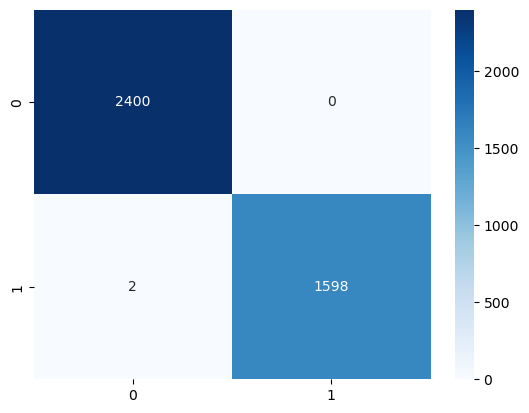

In [24]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()